# Eksplorujemy modele `speech-to-text`: `openai/whisper-1`

## Czym jest model `whisper-1`?
 
* Model `whisper-1` jest modelem do rozpoznawania mowy.
* Dostępny jest za pośrednictwem API OpenAI.
* Model ten jest w stanie rozpoznać mowę w wielu językach.
* Potrafi zwrócić cały tekst na raz lub pojedyńcze słowa i zdania wraz z czasem ich wystąpienia.
* Wejście: nagranie audio
* Wyjście: tekst oraz opcjonalnie czas wystąpienia słów


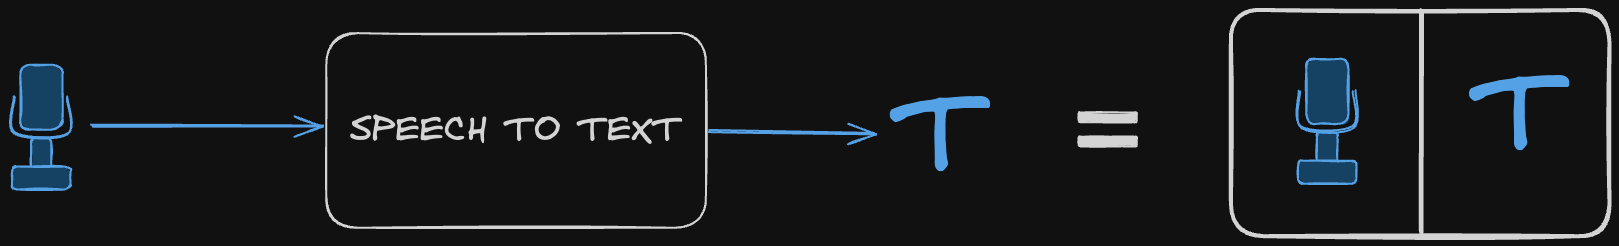

## Koszty

* Modele do rozpoznawania mowy są dość tanie.
* Naliczanie jest minutowe (zaokrąglane do sekund).
* W przypadku modelu `whisper-1` koszt wynosi $0.006 za minutę.

Przykładowe estymacje:
* Dla nagrania, które trwa `10 minut`, koszt wyniesie `$0.06` (czyli około `0.24 PLN`)
* W przypadku transkrypcji filmu, który trwa `2 godziny`, koszt wyniesie `$0.72` (czyli około `2.88 PLN`)
* Jeżeli twoja aplikacja zajmuje się generowaniem napisów dla filmów do `10 minut`, średnio użytkownik konwertuje `5` filmów dziennie, to koszt per użytkownik wyniesie `5 * 10 * 30 * 0.006 = $9` (czyli około `36 PLN`) miesięcznie (przyjęliśmy `30` dni w miesiącu).

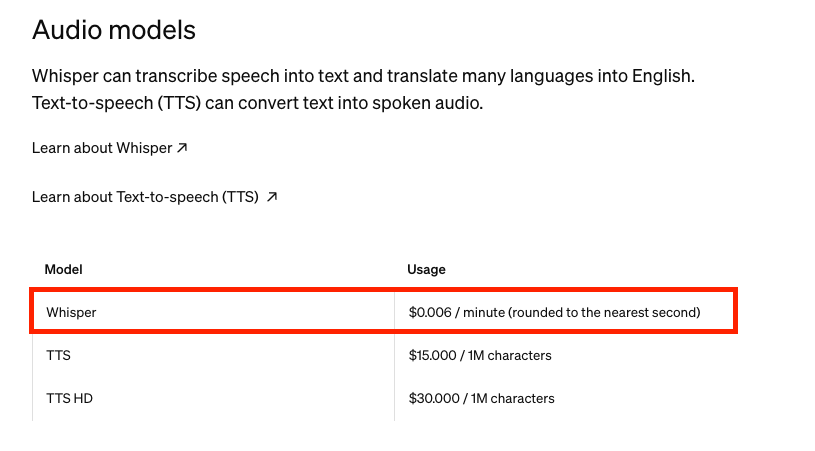

## Instalujemy wymagane biblioteki (conda wymagana)

- otwórz terminal
- uruchom `conda activate od_zera_do_ai`
- uruchom `conda install -y ffmpeg pydub openai==1.47.0 python-dotenv`

In [ ]:
from dotenv import dotenv_values
from IPython.display import Markdown
from pydub import AudioSegment
from io import BytesIO
from openai import OpenAI

In [ ]:
env = dotenv_values(".env")

openai_client = OpenAI(api_key=env["OPENAI_API_KEY"])

## Jak używać modelu `whisper-1` do rozpoznawania mowy?

In [ ]:
with open("audio_about_ai.mp3", "rb") as f:
    transcript = openai_client.audio.transcriptions.create(
        file=f,
        model="whisper-1",
    )

In [ ]:
Markdown(transcript.text)

In [ ]:
# sprawdźmy jak dobrze `whisper-1` poradził sobie z tekstem
with open("audio_about_ai.txt", "r") as f:
    print(f.read())

## Jak używać modelu `whisper-1` do rozpoznanie języka mówionego?

In [ ]:
with open("audio_about_ai.mp3", "rb") as f:
    transcript = openai_client.audio.transcriptions.create(
        file=f,
        model="whisper-1",
        response_format="verbose_json",
    )

In [ ]:
transcript.language

## Jak używać modelu `whisper-1` do detekcji wystąpień słów?

In [ ]:
with open("audio_about_ai.mp3", "rb") as f:
    transcript = openai_client.audio.transcriptions.create(
        file=f,
        model="whisper-1",
        response_format="verbose_json",
        timestamp_granularities=["word", "segment"],
    )

In [ ]:
transcript.words

## Jak używać modelu `whisper-1` generowania napisów w formacie `srt`?

In [ ]:
with open("audio_about_ai.mp3", "rb") as f:
    transcript = openai_client.audio.transcriptions.create(
        file=f,
        model="whisper-1",
        response_format="srt",
    )

In [ ]:
print(transcript)

In [ ]:
with open("audio_about_ai.srt", "w") as f:
    f.write(transcript)

## Zamykamy model w funkcji

In [ ]:
def detect_language_of_audio(audio_path, based_on_seconds=10):
    b = BytesIO()
    seg = AudioSegment.from_file(audio_path)
    seq_fragment = seg[:based_on_seconds * 1000]
    seq_fragment.export(b, format="mp3")
    b.name = "audio.mp3"
    with open(audio_path, "rb") as f:
        transcript = openai_client.audio.transcriptions.create(
            file=b,
            model="whisper-1",
            response_format="verbose_json",
        )

    return transcript.language

In [ ]:
detect_language_of_audio("audio_about_ai.mp3")

In [ ]:
def transcribe_audio_to_text(audio_path):
    with open(audio_path, "rb") as f:
        transcript = openai_client.audio.transcriptions.create(
            file=f,
            model="whisper-1",
            response_format="verbose_json",
        )

    return transcript.text

In [ ]:
transcribe_audio_to_text("audio_about_ai.mp3")

In [ ]:
def transcribe_audio_to_words(audio_path):
    with open(audio_path, "rb") as f:
        transcript = openai_client.audio.transcriptions.create(
            file=f,
            model="whisper-1",
            response_format="verbose_json",
            timestamp_granularities=["word"],
        )

    return transcript.words

In [ ]:
words_and_times = transcribe_audio_to_words("audio_about_ai.mp3")

In [ ]:
for word_and_time in words_and_times:
    print(word_and_time["word"].upper(), "pada w czasie:", word_and_time["start"])

In [ ]:
def generate_subtitles(audio_path, subtitles_path):
    with open(audio_path, "rb") as f:
        transcript = openai_client.audio.transcriptions.create(
            file=f,
            model="whisper-1",
            response_format="srt",
        )

    with open(subtitles_path, "w") as f:
        f.write(transcript)

    return transcript

In [ ]:
generate_subtitles("audio_about_ai.mp3", "audio_about_ai.srt")

## Pomysły `gpt-4o` na użycie modelu

### 1. Generowanie Napisy do Filmów i Wideo
Model AI może automatycznie transkrybować dialogi z filmów, seriali, czy wideoklipów, generując dokładne napisy, które mogą być używane do tworzenia wersji z napisami dla osób niesłyszących, dla tłumaczeń lub do SEO wideo.

### 2. Automatyczne Podsumowanie Lekcji Po Zajęciach z Nauczycielem
Podczas zajęć z nauczycielem (np. lekcji języka angielskiego) AI może przekształcać mówione treści w notatki lub podsumowanie lekcji, które uczniowie mogą przeglądać po zajęciach. Dzięki temu mogą lepiej zrozumieć materiał i przyswoić kluczowe informacje.

### 3. Transkrypcja Spotkań i Konferencji
AI może automatycznie transkrybować treści zebrane podczas spotkań biznesowych, konferencji, czy rozmów online, tworząc dokładny zapis, który można później przeszukiwać, udostępniać lub wykorzystywać do tworzenia protokołów.

### 4. Tworzenie Notatek z Wykładów i Szkolenia
Model AI może być używany do transkrypcji wykładów akademickich, webinariów lub szkoleń, tworząc szczegółowe notatki dla uczestników. Dzięki temu mogą wrócić do materiału po zakończeniu zajęć i lepiej go zrozumieć.

### 5. Rozpoznawanie i Tłumaczenie Przemówień w Czasie Rzeczywistym
AI może być używany do przekształcania przemówień na tekst, a następnie tłumaczenia tego tekstu na inne języki w czasie rzeczywistym. Może to być przydatne podczas międzynarodowych konferencji i spotkań.

### 6. Automatyczne Tworzenie Blogów i Artykułów na Podstawie Podcastów
Model AI może transkrybować treści podcastów i generować z nich artykuły blogowe. Dzięki temu podcasty mogą być przekształcone w pisemne treści, które są dostępne dla szerszego grona odbiorców.

### 7. Wspieranie Naukę Języków Poprzez Odkrywanie Nowych Słówek
AI może analizować rozmowy podczas lekcji języka obcego, wyodrębniać nowe słówka i tworzyć dla uczniów listy nowych wyrazów do nauki. Może także tworzyć kontekstowe podsumowania użycia tych słów.

### 8. Automatyczne Tworzenie Transkrypcji Wywiadów Dla Dziennikarzy
Dziennikarze mogą używać modelu AI do automatycznej transkrypcji wywiadów, co przyspiesza proces redagowania artykułów, umożliwiając szybkie przeszukiwanie i analizowanie materiałów dźwiękowych.

### 9. Tworzenie Dialogów Dla Chatbotów na Podstawie Rozmów z Klientami
Model AI może analizować rozmowy z klientami i na tej podstawie generować skrypty dialogów dla chatbotów, które mogą być używane do automatyzacji obsługi klienta, zwiększając jakość i spójność komunikacji.

### 10. Automatyczne Rozpoznawanie i Transkrypcja Wykładów Konferencyjnych
AI może przekształcać mowę z wykładów na konferencjach w tekst, który może być później udostępniany uczestnikom jako materiały referencyjne, artykuły konferencyjne lub publikacje.